In [42]:
from CustomCNN import CustomCNN
import torch

from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

In [43]:
# Load the pre-trained model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CustomCNN(num_classes=7)  # Ensure the number of output classes matches your dataset
# Load the state_dict from the file
state_dict = torch.load("custom_v2_7.pth", map_location=device, weights_only=True)

model.load_state_dict(state_dict)
model.to(device)
model.eval()

CustomCNN(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv5): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn5): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_

In [44]:
val_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((256, 256)),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
dataset = datasets.ImageFolder('./dataset_old', transform=val_transforms)  # Update path to your dataset
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
val_loader = DataLoader(dataset, batch_size=32, shuffle=False)

Confusion Matrix
[[2742    0    0    0    0    0    0]
 [   1 3637    0   23    0    0    4]
 [   0    0 3152    0    0    0    0]
 [  13   30    6 3166   10    3    8]
 [   0    0    0    0 2632    0    0]
 [   0    0    0    0    0 3000    0]
 [   2    0    0    6    2    0 2867]]


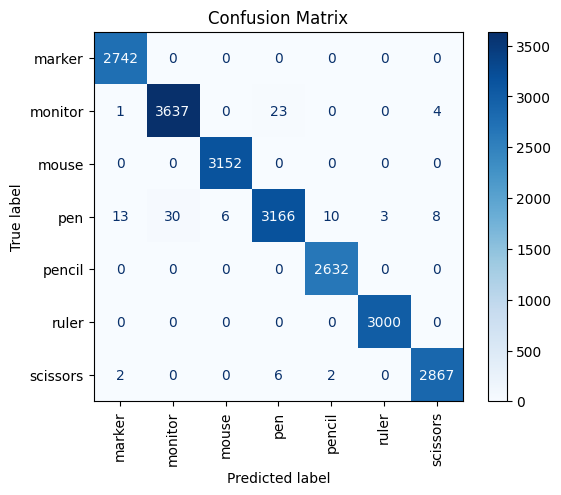

Classification Report
              precision    recall  f1-score   support

      marker       0.99      1.00      1.00      2742
     monitor       0.99      0.99      0.99      3665
       mouse       1.00      1.00      1.00      3152
         pen       0.99      0.98      0.98      3236
      pencil       1.00      1.00      1.00      2632
       ruler       1.00      1.00      1.00      3000
    scissors       1.00      1.00      1.00      2877

    accuracy                           0.99     21304
   macro avg       1.00      1.00      1.00     21304
weighted avg       0.99      0.99      0.99     21304


In [45]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

# collecting true and predicted labels for performance metrics
y_true, y_pred = [], []
model.eval()
with torch.no_grad():
  for inputs, labels in val_loader:
    inputs, labels = inputs.to(device), labels.to(device)
    outputs = model(inputs)
    _, preds = torch.max(outputs, 1)
    y_true.extend(labels.cpu().numpy())
    y_pred.extend(preds.cpu().numpy())

# confusion matrix
  conf_matrix = confusion_matrix(y_true, y_pred)
  print("Confusion Matrix")
  print(conf_matrix)

  disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=train_dataset.dataset.classes)
  disp.plot(cmap=plt.cm.Blues, xticks_rotation="vertical")
  plt.title("Confusion Matrix")
  plt.show()

# classification report
class_report = classification_report(y_true, y_pred, target_names=train_dataset.dataset.classes)
print("Classification Report")
print(class_report)